In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

**Dataset Preparation and Preprocessing:**

In [29]:
train_dir = '/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Train'
test_dir  = '/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Test'

In [32]:
img_height, img_width = 28, 28

def load_images_only(folder):
    images = []
    class_names = sorted(os.listdir(folder))

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0

            images.append(img)

    return np.array(images)

In [34]:
x_train = load_images_only(train_dir)
x_test = load_images_only(test_dir)

print(x_train.shape, x_test.shape)

(17031, 28, 28) (3000, 28, 28)


In [35]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

In [36]:
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(0.0, 1.0, x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(0.0, 1.0, x_train.shape)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(0.0, 1.0, x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(0.0, 1.0, x_test.shape)

In [37]:
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

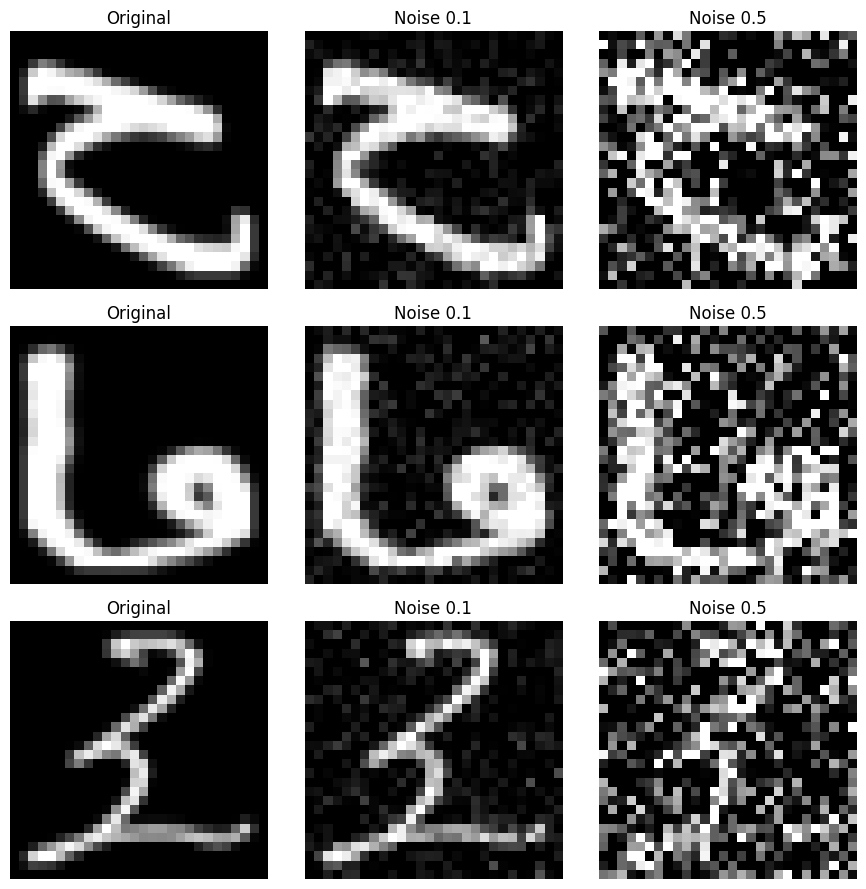

In [38]:
n = 3
random_indices = np.random.choice(len(x_train), n, replace=False)

plt.figure(figsize=(9, 9))

for i, idx in enumerate(random_indices):
    # Original
    plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low noise
    plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[idx].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise
    plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[idx].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Build the Denoising Convolutional Autoencoder:**

In [40]:
def build_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2,2))(x)

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)

    decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    return autoencoder

In [41]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

**Train the Denoising Autoencoder:**

In [42]:
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy_high, x_test),
    shuffle=True
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 60s 430ms/step - loss: 0.3098 - val_loss: 0.2189
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 78s 406ms/step - loss: 0.2097 - val_loss: 0.2014
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 403ms/step - loss: 0.2002 - val_loss: 0.1967
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 56s 416ms/step - loss: 0.1956 - val_loss: 0.1942
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 415ms/step - loss: 0.1926 - val_loss: 0.1991
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 406ms/step - loss: 0.1910 - val_loss: 0.1890
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 57s 422ms/step - loss: 0.1888 - val_loss: 0.1911
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 413ms/step - loss: 0.1881 - val_loss: 0.1868
Epoch 9/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 408ms/step - loss: 0.1866 - val_loss: 0.1866
Epoch 10/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 54s 401ms/step - loss: 0.1856 - val_loss: 0.1849


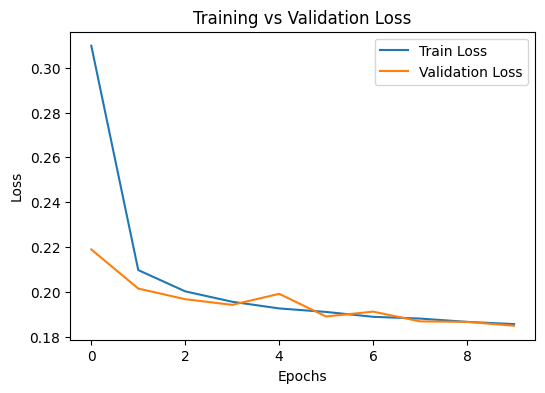

In [43]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [44]:
denoised_images = autoencoder.predict(x_test_noisy_high)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step


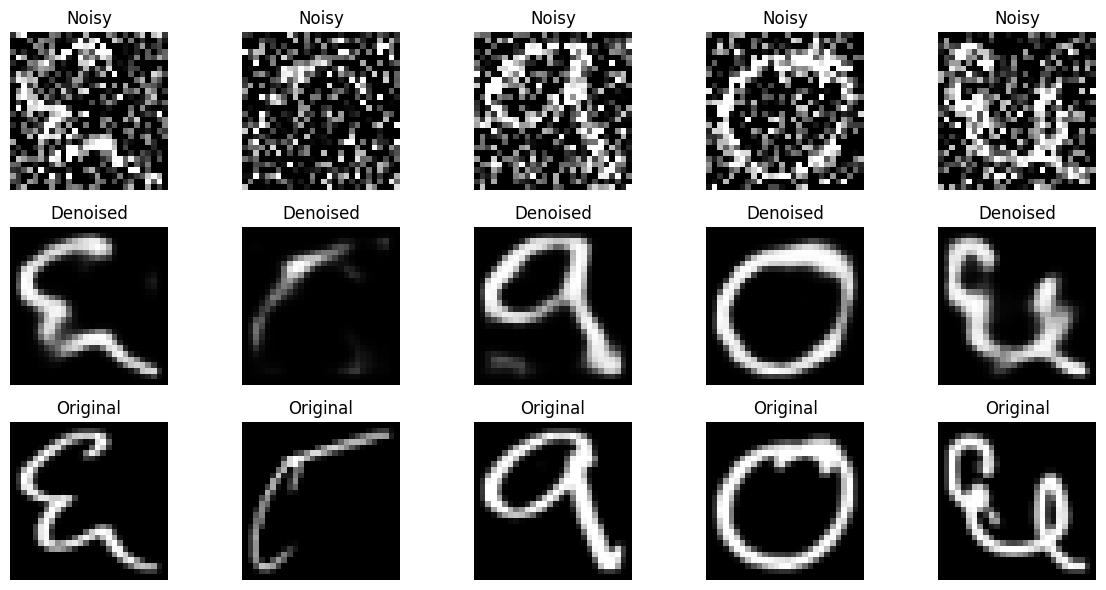

In [45]:
n = 5
indices = np.random.choice(len(x_test), n, replace=False)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):

    # Noisy
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy_high[idx].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[idx].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Original
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()